In [12]:
def extract_date_from_filename(filepath: str) -> str:
    """Extract date in YYYYMMDD format from a file path.
    
    Args:
        filepath: Path to the file containing a date
        
    Returns:
        str: Date in YYYYMMDD format
        
    Example:
        >>> path = '../datasets/Craig_scans/20130801/HumanStabiltiy_130801_4_1.PAR'
        >>> extract_date_from_filename(path)
        '20130801'
    """
    import re
    
    # Extract 8 consecutive digits that represent a date (YYYYMMDD)
    match = re.search(r'20\d{6}', filepath)
    if match:
        return match.group(0)
    else:
        raise ValueError(f"Could not find date in filepath: {filepath}")

In [15]:
import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

def list_and_plot_random_niftis(data_dir: str, n_samples: int = 4):
    """List NIFTI files from directory and plot random selections.
    
    Args:
        data_dir: Directory containing NIFTI files
        n_samples: Number of random samples to plot (default: 8)
    """
    # List all NIFTI files
    nifti_files = [f for f in os.listdir(data_dir) 
                   if f.endswith('.nii') or f.endswith('.nii.gz')]
    print(nifti_files)
    
    if len(nifti_files) < n_samples:
        print(f"Warning: Only {len(nifti_files)} files found, using all available files")
        selected_files = nifti_files
    else:
        selected_files = random.sample(nifti_files, n_samples)
    
    # Create subplot grid
    rows = (n_samples + 1) // 2  # Ceiling division
    cols = min(n_samples, 2)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    fig.suptitle('Random NIFTI Samples (Mid Z-Slice)', fontsize=16)
    
    # Flatten axes for easier indexing if multiple rows
    if rows > 1:
        axes = axes.flatten()
    
    # Plot each selected file
    for idx, fname in enumerate(selected_files):
        # Load NIFTI file
        img = nib.load(os.path.join(data_dir, fname))
        data = img.get_fdata()
        
        # Get middle z-slice
        mid_z = data.shape[2] // 2
        
        # Plot in appropriate subplot
        if rows == 1:
            ax = axes[idx] if cols > 1 else axes
        else:
            ax = axes[idx]
        
        im = ax.imshow(data[:, :, mid_z].T, cmap='gray')
        date = extract_date_from_filename(fname)
        ax.set_title(f'{date}\nSlice {mid_z}/{data.shape[2]}')
        ax.axis('off')
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.savefig('random_niftis.png')
    plt.show()
    
    return selected_files


['human_brain_20100513.nii.gz', 'human_brain_20111103.nii.gz', 'human_brain_20120126.nii.gz', 'human_brain_20130926.nii.gz', 'human_brain_20110428.nii.gz', 'human_brain_20121108.nii.gz', 'human_brain_20111117.nii.gz', 'human_brain_20100407.nii.gz', 'human_brain_20130613.nii.gz', 'human_brain_20120726.nii.gz', 'human_brain_20110224.nii.gz', 'human_brain_20110324.nii.gz', 'human_brain_20130314.nii.gz', 'human_brain_20110707.nii.gz', 'human_brain_20120425.nii.gz', 'human_brain_20130510.nii.gz', 'human_brain_20120315.nii.gz', 'human_brain_20130703.nii.gz', 'human_brain_20130131.nii.gz', 'human_brain_20120919.nii.gz', 'human_brain_20130801.nii.gz', 'human_brain_20100204.nii.gz', 'human_brain_20100304.nii.gz', 'human_brain_20110120.nii.gz', 'human_brain_20110915.nii.gz', 'human_brain_20100916.nii.gz', 'human_brain_20131114.nii.gz', 'human_brain_20110610.nii.gz', 'human_brain_20120103.nii.gz', 'human_brain_20120607.nii.gz', 'human_brain_20101111.nii.gz', 'human_brain_20130403.nii.gz', 'human_

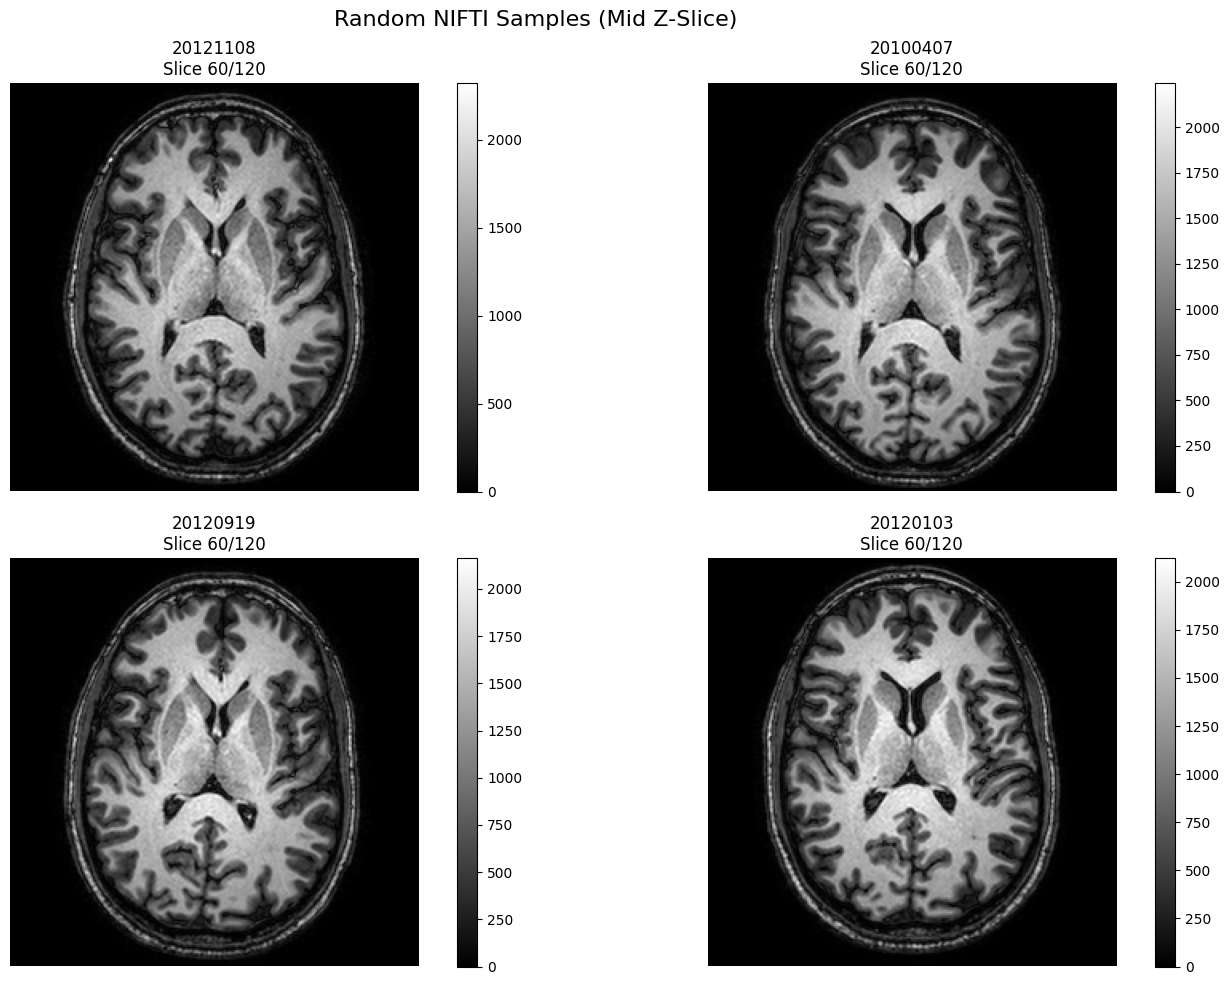


Selected files:
- human_brain_20121108.nii.gz
- human_brain_20100407.nii.gz
- human_brain_20120919.nii.gz
- human_brain_20120103.nii.gz


In [16]:
# Example usage
data_dir = "../../datasets/Craig_scans/T1_nifti"  # Adjust path as needed
selected_files = list_and_plot_random_niftis(data_dir)
print("\nSelected files:")
for f in selected_files:
    print(f"- {f}")